## Calculation of the sparsity coefficients for trained networks 

In [2]:
import numpy as np
import json


In [15]:

# load the K matrix  

drift_list= np.array([0.0, 0.00001, 0.00005, 0.0001, 0.001, 0.005])
ndrifts=drift_list.size

list_noise = np.array([0.0, 0.125, 0.5, 2.0])
nnoises = len(list_noise)

s_list = [[np.array([]) for _ in range(ndrifts)] for _ in range(nnoises)]

for index, noise in enumerate(list_noise):

    #s_list[index] = [np.array([]) for _ in range(ndrifts)]

    for ii, drift in enumerate(['0.0', '0.00001', '0.00005', '0.0001', '0.001', '0.005']):

        for ipatt in range(1, 49):

            k_file = f'noise_{noise}/run_dr{drift}_ns{noise}_patt{ipatt}/K_matrix_D2.json'
            try:
                with open(k_file, 'r') as file:
                    k_data = json.load(file)
                    Kmatrix = np.array(k_data['K'])
                    Kmatrix = np.maximum(Kmatrix, 1.0) 
                    Klinear = Kmatrix.flatten()
                    s = np.sqrt(np.var(np.log(Klinear))) / np.mean(np.log(Klinear))  # variance/mean ratio of the K matrix (conditional on the components K > 1)
                    if not np.isnan(s) and not np.isinf(s):
                        s_list[index][ii] = np.append(s_list[index][ii], s)  
            except FileNotFoundError:
                    print(f"File not found: {k_file}")
            except json.JSONDecodeError:
                print(f"Error decoding JSON in file: {k_file}")




drift_list= np.array([0.0, 0.00001, 0.00005, 0.0001, 0.001, 0.005])

File not found: noise_0.125/run_dr0.0_ns0.125_patt11/K_matrix_D2.json
File not found: noise_0.125/run_dr0.0_ns0.125_patt44/K_matrix_D2.json
File not found: noise_0.125/run_dr0.0_ns0.125_patt45/K_matrix_D2.json
File not found: noise_0.125/run_dr0.0_ns0.125_patt46/K_matrix_D2.json
File not found: noise_0.125/run_dr0.0_ns0.125_patt47/K_matrix_D2.json
File not found: noise_0.125/run_dr0.00001_ns0.125_patt21/K_matrix_D2.json
File not found: noise_0.125/run_dr0.00001_ns0.125_patt46/K_matrix_D2.json
File not found: noise_0.125/run_dr0.00005_ns0.125_patt10/K_matrix_D2.json
File not found: noise_0.5/run_dr0.0_ns0.5_patt2/K_matrix_D2.json
File not found: noise_0.5/run_dr0.0001_ns0.5_patt1/K_matrix_D2.json
File not found: noise_0.5/run_dr0.0001_ns0.5_patt2/K_matrix_D2.json
File not found: noise_2.0/run_dr0.0_ns2.0_patt2/K_matrix_D2.json
File not found: noise_2.0/run_dr0.0_ns2.0_patt4/K_matrix_D2.json
File not found: noise_2.0/run_dr0.0_ns2.0_patt5/K_matrix_D2.json
File not found: noise_2.0/run_dr

C:\Users\Admi\AppData\Local\Temp\ipykernel_20756\1730764915.py:26: RuntimeWarning: invalid value encountered in scalar divide
  s = np.sqrt(np.var(np.log(Klinear))) / np.mean(np.log(Klinear))  # variance/mean ratio of the K matrix (conditional on the components K > 1)


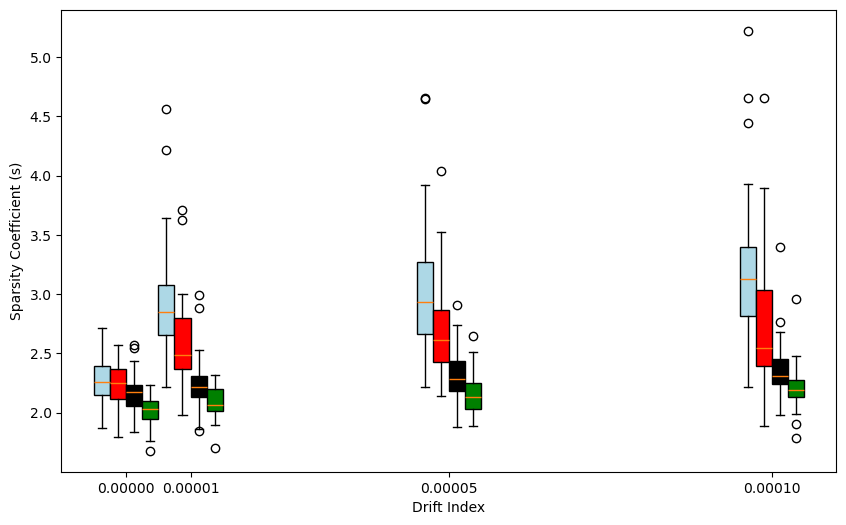

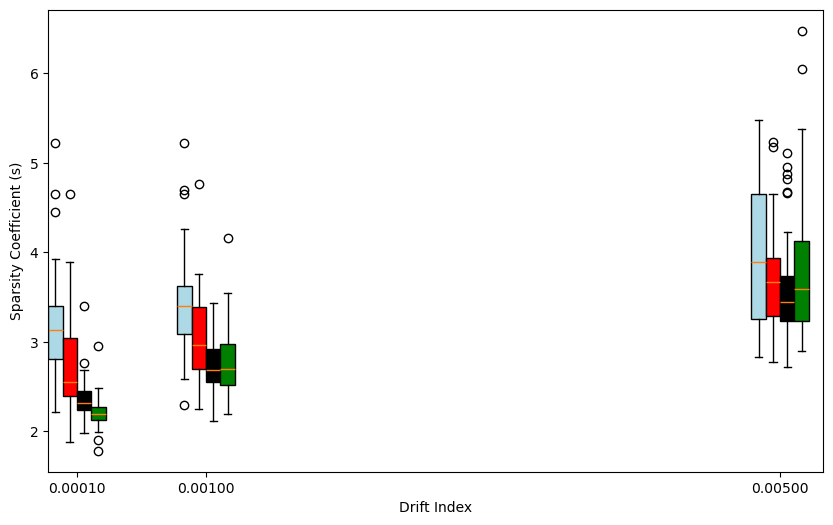

In [16]:
import numpy as np
import matplotlib.pyplot as plt


drift_list= np.array([0.0, 0.00001, 0.00005, 0.0001])


widths=0.0000025
plt.figure(figsize=(10, 6))
plt.boxplot(s_list[0][:4], patch_artist=True, boxprops=dict(facecolor="lightblue"), positions=drift_list-1.5*widths, widths=widths)
plt.boxplot(s_list[1][:4], patch_artist=True, boxprops=dict(facecolor="red"), positions=drift_list-0.5*widths, widths=widths)
plt.boxplot(s_list[2][:4], patch_artist=True, boxprops=dict(facecolor="black"), positions=drift_list+0.5*widths, widths=widths)
plt.boxplot(s_list[3][:4], patch_artist=True, boxprops=dict(facecolor="green"), positions=drift_list+1.5*widths, widths=widths)


# Add labels and title
plt.xlabel("Drift Index")
plt.ylabel("Sparsity Coefficient (s)")

# Adjust x-axis range to match the positions
plt.xlim([-drift_list[1], drift_list[-1] + drift_list[1]])
plt.xticks(drift_list, labels=[f"{x:.5f}" for x in drift_list])  # Set tick labels based on drift_list

plt.show()


drift_list= np.array([0.0001, 0.001, 0.005])

widths=0.0001
plt.figure(figsize=(10, 6))
plt.boxplot(s_list[0][-3:], patch_artist=True, boxprops=dict(facecolor="lightblue"), positions=drift_list-1.5*widths, widths=widths)
plt.boxplot(s_list[1][-3:], patch_artist=True, boxprops=dict(facecolor="red"), positions=drift_list-0.5*widths, widths=widths)
plt.boxplot(s_list[2][-3:], patch_artist=True, boxprops=dict(facecolor="black"), positions=drift_list+0.5*widths, widths=widths)
plt.boxplot(s_list[3][-3:], patch_artist=True, boxprops=dict(facecolor="green"), positions=drift_list+1.5*widths, widths=widths)

# Add a legend
#plt.legend() #["Noise 0.0", "Noise 0.125"])#, loc="upper left")

# Add labels and title
plt.xlabel("Drift Index")
plt.ylabel("Sparsity Coefficient (s)")

# Adjust x-axis range to match the positions
plt.xlim([-drift_list[0], drift_list[-1]+drift_list[0]+2*widths])
plt.xticks(drift_list, labels=[f"{x:.5f}" for x in drift_list])  # Set tick labels based on drift_list


plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))
plt.boxplot(s_list[], patch_artist=True, boxprops=dict(facecolor="lightblue"), widths=0.1)

# Add labels and title
plt.xlabel("Drift Index")
plt.ylabel("Sparsity Coefficient (s)")

# Calculate the average value of s_list for each drift
s_avg = [np.mean(s) for s in s_list]

# Fit a linear regression model in log-log scale
log_s_avg = np.log10(s_avg[1:])  # Exclude corresponding zero index
coeffs = np.polyfit(log_drift_list, log_s_avg, deg=1)  # Linear fit in log-log scale
slope, intercept = coeffs

# Generate points for the fitted line in log-log scale
fit_x = np.linspace(min(log_drift_list), max(log_drift_list), 100)
fit_y = slope * fit_x + intercept

# Convert back to original scale for plotting
fit_x_original = 10**fit_x
fit_y_original = 10**fit_y

# Plot the scatter plot and the fitted line
plt.scatter(log_drift_list, s_avg[1:], color='blue', label='Average Sparsity Coefficient')
plt.plot(fit_x, fit_y_original, color='red', linestyle='--', label=f'Fit: y = {10**intercept:.2f}x^{slope:.2f}')

# Add labels, title, and legend
plt.title("n/s=0% (Power Law Fit)")
plt.legend()

# Use logarithmic scale for x-axis
plt.xticks(log_drift_list, labels=[f"{10**x:.5f}" for x in log_drift_list])  # Custom tick labels
 Ensure log_drift_list Ensure is log_drift_list defined
log_drift_list is = defined np.log10(drift_list[1:])
log_drift_list  # = Exclude np.log10(drift_list[1:]) zero to  # avoid Exclude log(0) zero

# to Create avoid a log(0) box plot

# for Create s_list a
plt.figure(figsize box= plot(10, 6)) for
plt.boxplot(s_list[1:], s_list patch_artist
plt.figure(figsize==True,(10, boxprops 6))=dict(facecolor
plt.boxplot(s_list[1:],= patch_artist"lightblue"),= positionsTrue,= boxpropslog_drift_list,= widths=dict(facecolor0.1)=

#"lightblue"), Add positions labels= and titlelog_drift_list,
plt.xlabel("Log(Drift widths Index)")=
plt.ylabel("Sparsity0.1) Coefficient

# (s)") Add

# Calculate labels the and average title value
plt.xlabel("Log(Drift of Index)") s_list for
plt.ylabel("Sparsity each Coefficient drift (s)")
s_avg

# = Calculate [np.mean(s) the for s average in value s_list] of

# s_list Fit for a each linear regression drift model
s_avg in = log [np.mean(s)- forlog scale s
log_s_avg in = s_list] np.log10(s_avg[1:])

#  # Fit Exclude a corresponding zero linear index regression
coeffs model = in np.polyfit(log_drift_list, log log_s_avg, deg-=log1) scale  #
log_s_avg Linear = fit np.log10(s_avg[1:]) in log  #- Excludelog corresponding scale zero
slope, index intercept
coeffs = coeffs =

# np.polyfit(log_drift_list, Generate log_s_avg, points deg for= the fitted1) line  # in Linear log fit- inlog log scale
fit_x- =log np.linspace(min(log_drift_list), scale max(log_drift_list),
slope, 100) intercept
fit_y = = slope coeffs *

# fit_x Generate + points intercept for

# Convert the back fitted to line original in scale log for- plotting
fit_x_originallog = scale 10**fit_x
fit_x
fit_y_original = = np.linspace(min(log_drift_list), 10**fit_y

# max(log_drift_list), Plot 100) the
fit_y scatter = plot slope and * the fitted fit_x line +
plt.scatter(log_drift_list, intercept s_avg[1:],

# color Convert='blue', back label to= original'Average scale Sparsity for Coefficient') plotting
plt.plot(fit_x, fit_y_original,
fit_x_original color == 10**fit_x'red',
fit_y_original linestyle == 10**fit_y'--

#', Plot label the= scatterf'Fit: plot y = and {10**intercept:.2f}x^{slope:.2f}') the

# fitted Add line labels,
plt.scatter(log_drift_list, title, s_avg[1:], and legend color
plt.title("n/s=='blue',0% label (Power= Law Fit)")'Average
plt.legend() Sparsity

# Coefficient') Use
plt.plot(fit_x, logarithmic fit_y_original, scale color for x=-'red',axis linestyle
plt.xticks(log_drift_list,= labels'=--[f"{10**x:.5f}" for', x label in= log_drift_list])f'Fit:  # y Custom tick = labels {10**intercept:.2f}x^{slope:.2f}')
plt.show()


# Add labels, title, and legend
plt.title("n/s=0% (Power Law Fit)")
plt.legend()

# Use logarithmic scale for x-axis
plt.xticks(log_drift_list, labels=[f"{10**x:.5f}" for x in log_drift_list])  # Custom tick labels
plt.show()
plt.show()


IndentationError: unexpected indent (3566639345.py, line 43)

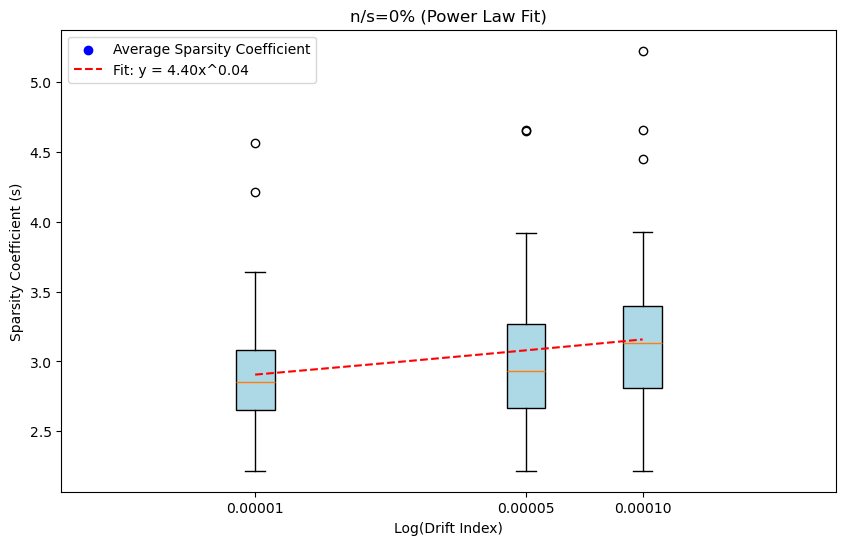

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Create a box plot for s_list
plt.figure(figsize=(10, 6))
plt.boxplot(s_list[1:], patch_artist=True, boxprops=dict(facecolor="lightblue"), positions=np.log10(drift_list[1:]), widths=0.1)

# Add labels and title
plt.xlabel("Log(Drift Index)")
plt.ylabel("Sparsity Coefficient (s)")

# Calculate the average value of s_list for each drift
s_avg = [np.mean(s) for s in s_list]

# Transform data to log-log scale
log_drift_list = np.log10(drift_list[1:])  # Exclude zero to avoid log(0)
log_s_avg = np.log10(s_avg[1:])  # Exclude corresponding zero index

# Fit a linear regression model in log-log scale
coeffs = np.polyfit(log_drift_list, log_s_avg, deg=1)  # Linear fit in log-log scale
slope, intercept = coeffs

# Generate points for the fitted line in log-log scale
fit_x = np.linspace(min(log_drift_list), max(log_drift_list), 100)
fit_y = slope * fit_x + intercept

# Convert back to original scale for plotting
fit_x_original = 10**fit_x
fit_y_original = 10**fit_y

# Plot the scatter plot and the fitted line
plt.scatter(log_drift_list, s_avg[1:], color='blue', label='Average Sparsity Coefficient')
plt.plot(fit_x, fit_y_original, color='red', linestyle='--', label=f'Fit: y = {10**intercept:.2f}x^{slope:.2f}')

# Add labels, title, and legend
plt.title("n/s=0% (Power Law Fit)")
plt.legend()

# Use logarithmic scale for x-axis
plt.xticks(log_drift_list, labels=[f"{10**x:.5f}" for x in log_drift_list])  # Custom tick labels
plt.show()